# Term Frequency Analyse af Kinesisk Tekst

## Script Summary

Dette notebook analyserer term frequency (ordfrekvens) i kinesiske tekster fra en SQLite database. Notebooket udfører følgende opgaver:

1. **Dataudtrækning**: Henter artikler fra en SQLite database baseret på søgeord og tidsperiode
2. **Tekstforbehandling**: Renser tekst, segmenterer kinesisk tekst med jieba, og fjerner stopord
3. **Term Frequency Beregning**: Beregner relativ ordfrekvens for alle ord i teksten
4. **Visualisering**: Opretter et bar plot der viser de 25 mest hyppige ord
5. **Dataeksport**: Gemmer resultaterne som CSV filer og visualiseringer som PNG billeder

### Funktioner

- **Databaseforbindelse**: Forbinder til SQLite database med kinesiske artikler
- **Filtrering**: Filtrerer artikler baseret på søgeord og datointerval
- **Tokenisering**: Bruger jieba til at segmentere kinesisk tekst
- **Stopord fjernelse**: Fjerner almindelige stopord fra analysen
- **Frekvensanalyse**: Beregner relativ frekvens for hvert ord
- **Visualisering**: Opretter bar plots for de mest hyppige ord

## 1. Dataudtrækning fra Database

Første step er at forbinde til databasen og udtrække artikler baseret på søgeord og tidsperiode. 

**Konfiguration:**
- `keyword`: Søgeordet der skal findes i artiklerne
- `time_from`: Startdato for søgningen
- `time_to`: Slutdato for søgningen

Artiklerne gemmes som en CSV fil i `./out/` mappen.

In [ ]:
import sqlite3
import pandas as pd

# Forbinder til SQLite databasen
conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()

# Konfiguration: Søgeord og tidsperiode
keyword = '我国'
time_from = '1977-09-01'
time_to = '1977-09-31'

# Uddrager artikler med søgeord i tidsperioden
# Søgeordet kan være i enten overskrift eller indhold
c.execute(f"SELECT * FROM rmrb WHERE content LIKE '%{keyword}%' AND (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
# Alternativ: Uddrag alle artikler i tidsperioden uden søgeord
#c.execute(f"SELECT * FROM rmrb WHERE (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
df = pd.DataFrame(c.fetchall())

# Omdøber kolonner
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})

# Gemmer tekstudtrækket som CSV fil
# Filnavnet inkluderer søgeord og tidsperiode
df.to_csv(fr'./out/{keyword}_{time_from}_{time_to}.csv', index=False)

## 2. Vis Data

Viser den udtrukne dataframe for at verificere at dataudtrækningen virkede korrekt.

In [ ]:
df

## 3. Tekstforbehandling og Tokenisering

Denne sektion forbehandler teksten og segmenterer den i individuelle ord (tokens).

**Process:**
1. **Tokenisering**: Bruger jieba til at segmentere kinesisk tekst
2. **Tekstrensning**: Fjerner whitespace og ekstraherer kun kinesiske tegn
3. **Stopord fjernelse**: Downloader og fjerner almindelige kinesiske stopord

Stopordene hentes fra en online kilde og bruges til at filtrere irrelevante ord fra analysen.

In [2]:
# tokenizer
import jieba_next as jieba
import re

def tokenizer(text_in):
    # clean text before tokenize
    text = text_in.replace(chr(0x3000),"") # 
    chinese_list = re.findall(r'[\u4e00-\u9fff]+', text) # unicode der viser at det følgende er kinesisk tekst
    chinese_text = ' '.join(chinese_list)
    
    # tokenize
    seg_list = jieba.lcut(chinese_text, cut_all=False)
    tokens = [item for item in seg_list if item != ' ']
    return tokens 

# Stopwords
from urllib.request import urlopen
target_url = 'https://sciencedata.dk/shared/93a217a0533d949d9b2c675cd3c99cfd?download'
sw_ch = urlopen(target_url).read().decode('utf-8').split()

# remove stopwords
def remove_stopwords(word_list):
    filtered_tokens = []
    for word in word_list:
        if word not in sw_ch:
            filtered_tokens.append(word)
    return filtered_tokens



# Preproces the text
text_in = ' '.join(df['Content'].to_list())
all_tokens = tokenizer(text_in)
tokens_wo_stopwords = remove_stopwords(all_tokens)

## 4. Beregning af Term Frequency

Beregner relativ term frequency (ordfrekvens) for alle ord i teksten. Relativ frekvens betyder at hvert ords frekvens divideres med det totale antal ord, hvilket giver en proportional værdi mellem 0 og 1.

Resultaterne sorteres efter frekvens (højeste først) og gemmes som CSV fil.

In [3]:
# compute relative term frequency
def compute_tf(word_list):
    tf_dict = {}
    total_words = len(word_list)
    for word in word_list:
        tf_dict[word] = tf_dict.get(word, 0) + 1
    for word in tf_dict:
        tf_dict[word] = tf_dict[word] / total_words
    return tf_dict


relative_feq = compute_tf(tokens_wo_stopwords)
relative_feq_df = pd.DataFrame(list(relative_feq.items()), columns=['Words', 'Relative_freq'])

# Sort the dataframe by 'Relative_freq' in descending order
relative_feq_df_sorted = relative_feq_df.sort_values(by='Relative_freq', ascending=False)

# save term frequency
relative_feq_df_sorted.to_csv(fr'./out/term_freq_{keyword}_{time_from}_{time_to}.csv', index=False)

## 5. Visualisering af Term Frequency

Opretter et bar plot der viser de 25 mest hyppige ord i artiklerne. 

**Bemærk**: På Mac skal fonten ændres til 'Heiti TC' i stedet for 'Microsoft YaHei' for at kunne vise kinesiske tegn korrekt.

Visualiseringen gemmes som PNG billede i `./out/` mappen.

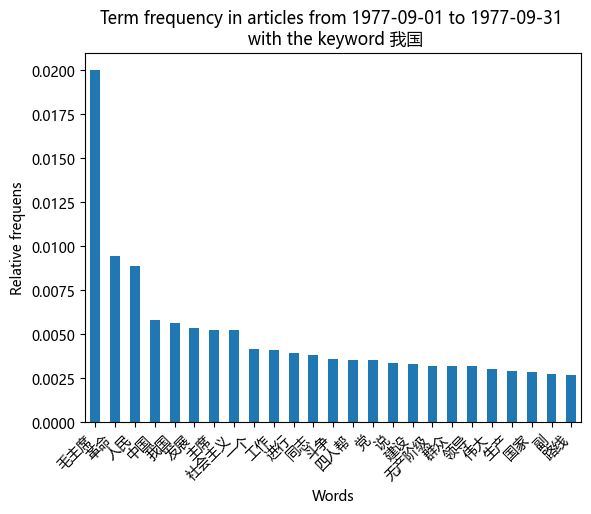

In [ ]:
# Visualise most common words
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Microsoft YaHei"  # husk på mac skal man bruge  'Heiti TC'

# Bar plot
# Viser de 25 mest hyppige ord
relative_feq_df_sorted.head(25).plot(kind='bar', x='Words', y='Relative_freq', legend=False)
plt.title(f'Term frequency in articles from {time_from} to {time_to} \n with the keyword {keyword}')
plt.xlabel('Words')
plt.ylabel('Relative frequens')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')


# save image
# use f-string and add the search terms to the file name
plt.savefig(fr'./out/term_freq_{keyword}_{time_from}_{time_to}_plot.png', bbox_inches='tight')
# Show
plt.show()

In [5]:
relative_feq_df_sorted.head(25)

,Words,Relative_freq
318,毛主席,0.019993
697,革命,0.009435
1011,人民,0.008887
924,中国,0.005821
13,我国,0.005618
18,发展,0.005327
236,主席,0.005232
251,社会主义,0.005218
5,一个,0.004129
142,工作,0.004101
